In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from pandas import DataFrame, Series

# Datos

In [2]:
P_separacion = 185 #psi
T_separacion = 95 #°F
densidad_relativa_del_gas = 0.65
densidad_del_aceite = 34 #°API
P_inicial = 2400 #psi
P_actual = 1500 #psi
T_yacimiento = 170 #°F
Rs_inicial = 425

# Cómputo

## Presión de burbujeo

#### Correlación de Standing modificada de De Ghetto et al. 1994

In [3]:
Pb = (31.7648 
      * (Rs_inicial / densidad_relativa_del_gas) ** 0.7857 
      * ((10 ** (0.0009 * T_yacimiento))/(10 ** (0.0148 * densidad_del_aceite))))

## Relación de solubilidad $Rs$

### (Condiciones Saturadas)

In [4]:
def Rs_s(P):
    DR_corregida_del_gas = (densidad_relativa_del_gas
                            * (1 
                               + 0.1595 
                               * densidad_del_aceite ** 0.4078
                               * T_separacion ** - 0.2466 
                               * math.log10(P_separacion/114.7)
                              )
                           )
    Rs_s = DR_corregida_del_gas * P ** 1.1535 / 37.966 * 10 ** (9.441 * densidad_del_aceite/(T_yacimiento + 460))
    return Rs_s

In [5]:
def Rs(P):
    if P > Pb:
        return Rs_inicial
    else:
        return Rs_s(P)

## Factor de volumen de aceite $Bo$

### Condiciones Saturadas $P ≤ P_b$

In [6]:
def Bo_s(P):
    DR_corregida_del_gas = (densidad_relativa_del_gas
                           * (1
                             + 5.912 
                              * 10 ** -5 
                              * densidad_del_aceite 
                              * T_yacimiento 
                              * math.log10(P_separacion/114.7)
                             )
                           )
    #Constantes para un aceite con densidad > 30 °APIA
    C1 = 4.670E-4
    C2 = 1.1E-5
    C3 = 1.337E-9
    Bo_s = (1 
            + C1 * Rs(P) 
            + C2 * (T_yacimiento - 60) * (densidad_del_aceite/DR_corregida_del_gas)
            + C3 * Rs(P) * (T_yacimiento-60) * (densidad_del_aceite/DR_corregida_del_gas)
           )
    return Bo_s

### Condiciones Bajosaturadas $P > P_b$

In [7]:
def Co(P):
    Co = (
        (1.705 
         * 10 ** -7 
         * Rs(Pb) ** 0.69357 
         * densidad_relativa_del_gas ** 0.1885 
         * densidad_del_aceite 
         * T_yacimiento ** 0.6729)
        / (P ** 0.5906)
    )
    return Co

In [8]:
def Bo_u(P):
    Bo_u = Bo_s(Pb) * (1 - Co(P) * (P - Pb))
    return Bo_u

In [9]:
def Bo(P):
    if P > Pb:
        return Bo_u(P)
    else:
        return Bo_s(P)

## Factor de volumen de dos fases $B_t$

### Factor de volumen del gas $B_g$

#### Factor de desviación $z$

In [10]:
def z(Tr, Pr):

    # Constantes de la ecuación de estado
    A1 = 0.3265
    A2 = -1.07
    A3 = -0.5339
    A4 = 0.01569
    A5 = -0.05165
    A6 = 0.5475
    A7 = -0.7361
    A8 = 0.1844
    A9 = 0.1056
    A10 = 0.6134
    A11 = 0.721

    # Valor inicial de Z
    Z = 1.0

    # Cálculo de la densidad reducida
    rho = 0.27 * Pr / (Z * Tr)

    # Constantes C
    c1 = A1 + (A2 / Tr) + (A3 / Tr**3) + (A4 / Tr**4) + (A5 / Tr**5)
    c2 = A6 + (A7 / Tr) + (A8 / Tr**2)
    c3 = A9 * ((A7 / Tr) + (A8 / Tr**2))
    c4 = (
        A10
        * (1 + A11 * rho**2)
        * (rho**2 / Tr**3)
        * math.exp(-A11 * rho**2)
    )

    # Iteración Newton-Raphson
    for i in range(100):

        zn = (
            1
            + (c1 * rho)
            + (c2 * rho**2)
            - (c3 * rho**5)
            + c4
        )

        fofz = Z - zn

        # Derivada de la función respecto a Z
        dfdz = (
            1
            + c1 * rho / zn
            + 2 * c2 * rho**2 / zn
            - 5 * c3 * rho**5 / zn
            + 2 * A10 * rho**2 / (zn * Tr**3)
            * (
                1
                + A11 * rho**2
                - (A11 * rho**2)**2
                * math.exp(-A11 * rho**2)
            )
        )

        # Newton-Raphson
        dz = -fofz / dfdz

        Z = Z + dz

        # Criterio de convergencia
        if abs(Z - zn) > 1e-8:

            rho = 0.27 * Pr / (Z * Tr)

            c4 = (
                A10
                * (1 + A11 * rho**2)
                * (rho**2 / Tr**3)
                * math.exp(-A11 * rho**2)
            )

        else:
            break

    return Z

In [11]:
def Bg(P):
    Ppc = (756.8 
           - 131.0 * densidad_relativa_del_gas 
           - 3.6 * densidad_relativa_del_gas ** 2)

    Tpc = (169.2 
           + 349.5 * densidad_relativa_del_gas 
           - 74 * densidad_relativa_del_gas ** 2)

    Pr = P / Ppc

    T_R = T_yacimiento + 459.67
    Tr = T_R / Tpc

    Z = z(Tr, Pr)

    Bg = 0.00504 * Z * T_R / P

    return Bg

In [12]:
def Bt(P):
    Bt = Bo(P) + Bg(P) * (Rs_inicial - Rs(P))
    return Bt

## Oil viscosity $\mu_o$

### Condiciones Saturadas $P ≤ P_b$

In [13]:
def mu_s(P):
    A = 10 ** ((0.43 + 8.33)/ densidad_del_aceite)
    Mu_OD = (0.32 + (1.8 * 10 ** 7)/(densidad_del_aceite ** 4.53)) * (360 / (T_yacimiento + 200) ** A)
    A1 = 10.715 * (Rs(P) + 100) ** -0.515
    A2 = 5.44 * (Rs(P) + 150) ** -0.338
    mu_s = A1 * Mu_OD ** A2
    return mu_s

### Condiciones Bajosaturadas $P > P_b$

In [14]:
def mu_u(P):
    B = 3.9 * 10 ** - 5 * P + 5
    A = 2.6 * P ** 1.187 * 10 ** - B
    mu_u = mu_s(Pb) * (P/Pb) ** A
    return mu_u

In [15]:
def mu(P):
    if P > Pb:
        return mu_u(P)
    else:
        return mu_s(P)

# Tabla de resultados

In [16]:
propiedades = [r"$Pb [psi]$",r"$B_(ob) [psi]$",r"$B_t$",r"$Rs$",r"$B_o$",r"$\mu_o[cp]$"]
presiones = [P_inicial, Pb, P_actual]

In [17]:
data = pd.DataFrame(index = propiedades, columns= presiones)

In [18]:
for presion in presiones:
    data.loc[propiedades[0],presion] = Pb
    data.loc[propiedades[1],presion] = Bo(Pb)
    data.loc[propiedades[2],presion] = Bt(presion)
    data.loc[propiedades[3],presion] = Rs(presion)
    data.loc[propiedades[4],presion] = Bo(presion)
    data.loc[propiedades[5],presion] = mu(presion)
    
data

,2400.000000,2311.347706,1500.000000
$Pb [psi]$,2311.347706,2311.347706,2311.347706
$B_(ob) [psi]$,1.267295,1.267295,1.267295
$B_t$,1.254239,1.25049,1.483636
$Rs$,425,439.060481,266.64105
$B_o$,1.254239,1.267295,1.185536
$\mu_o[cp]$,0.035346,0.035061,0.031414


# Analisis

In [19]:
x = np.linspace(P_inicial,P_separacion,100)
y = np.zeros_like(x)
for i in range(len(y)):
    y[i] = Bo(x[i])

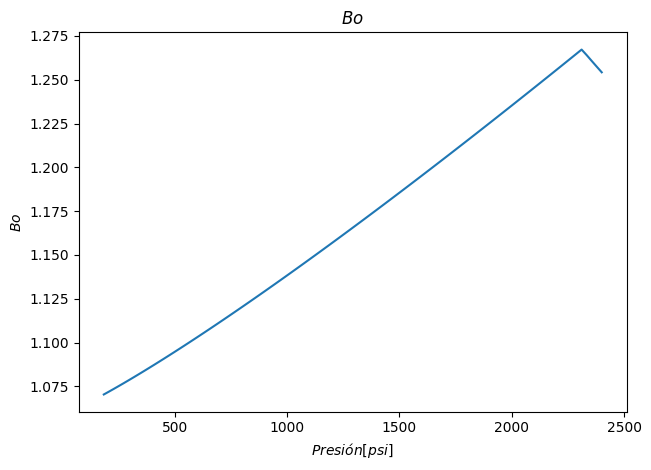

In [20]:
propiedad = "Bo"
plt.title(f"${propiedad}$")
plt.xlabel(r"$Presión [psi]$")
plt.ylabel(f"${propiedad}$")
plt.tight_layout()
plt.plot(x,y)